# Generalized Matrix Factorization (GMF)

Modelo de **Neural Collaborative Filtering (NCF)** propuesto por He et al. (2017). GMF generaliza la factorización matricial clásica (PMF) usando embeddings aprendidos por la red. La arquitectura es:

$$\hat{r}_{u,i} = \sigma(\mathbf{w}^T (\mathbf{p}_u \odot \mathbf{q}_i))$$

donde $\mathbf{p}_u, \mathbf{q}_i \in \mathbb{R}^d$ son los embeddings de usuario e ítem, $\odot$ es el producto Hadamard, y $\mathbf{w}$ es una capa lineal que combina las dimensiones del producto.

**Diferencia con PMF**: PMF puro hace $\hat{r} = \mathbf{p}_u^T \mathbf{q}_i$ (producto escalar con pesos uniformes). GMF añade la capa Linear que permite a la red **aprender pesos distintos por dimensión latente**.

---

### Modo de ejecución

Este notebook está diseñado para ser **reanudable**. Las celdas de entrenamiento comprueban primero si los resultados ya están guardados en Drive:
- **Primera ejecución (sin checkpoints)**: ~2 horas (grid search + 3 reentrenamientos).
- **Re-ejecución (con checkpoints)**: ~5 minutos (solo carga + plots).

Para forzar reentrenamiento, basta con borrar el archivo correspondiente de Drive.

## 1. Setup

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import time, json, sys, copy, os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Device: cpu


### 1.2. Carga de datos procesados

In [18]:
BASE = '../'
PATH_DATA = os.path.join(BASE, 'data', 'processed')

# Carga de datos
df_train = pd.read_csv(os.path.join(PATH_DATA, 'train.csv'))
df_test = pd.read_csv(os.path.join(PATH_DATA, 'test.csv'))

print(f"Train: {df_train.shape}")
print(f"Test:  {df_test.shape}")

Train: (6710683, 6)
Test:  (1940068, 6)


In [19]:
num_users = df_train['user_n'].max() + 1
num_items = df_train['track_n'].max() + 1
print(f"Num users (para Embedding): {num_users}")
print(f"Num items (para Embedding): {num_items}")

Num users (para Embedding): 533689
Num items (para Embedding): 23629


### 1.3. Definición del modelo GMF

In [20]:
class GMF(nn.Module):
    def __init__(self, num_users, num_items, latent_dim):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, latent_dim)
        self.item_emb = nn.Embedding(num_items, latent_dim)
        self.output = nn.Linear(latent_dim, 1)

    def forward(self, user_ids, item_ids):
        u = self.user_emb(user_ids)
        i = self.item_emb(item_ids)
        prod = u * i
        out_lineal = self.output(prod)

        pred = torch.sigmoid(out_lineal) * 4.0 + 1.0
        return pred.squeeze()

### 1.4. Preparación de tensores en GPU

In [21]:
user_train = torch.LongTensor(df_train['user_n'].values).to(device)
item_train = torch.LongTensor(df_train['track_n'].values).to(device)
rating_train = torch.FloatTensor(df_train['rating'].values).to(device)
td_train = TensorDataset(user_train, item_train, rating_train)

user_test = torch.LongTensor(df_test['user_n'].values).to(device)
item_test = torch.LongTensor(df_test['track_n'].values).to(device)
rating_test = torch.FloatTensor(df_test['rating'].values).to(device)

C:\Users\rfern\AppData\Local\Temp\ipykernel_26348\3684462054.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  user_train = torch.LongTensor(df_train['user_n'].values).to(device)


### 1.5. Funciones de entrenamiento y evaluación

In [22]:
def evaluar_modelo(modelo, dataloader, loss_fn):
    """
    Calcula la pérdida media (MSE) sobre cualquier dataloader.
    Se utilizará tanto para validación durante el entrenamiento como para el test final.
    """
    modelo.eval()
    loss_total, n_muestras = 0, 0
    with torch.no_grad():
        for users, items, ratings in dataloader:
            preds = modelo(users, items)
            loss = loss_fn(preds, ratings)
            loss_total += loss.item() * len(ratings)
            n_muestras += len(ratings)
    return loss_total / n_muestras


def entrenar_modelo(modelo, train_loader, lr, num_epocas, val_loader=None, paciencia=3, verbose=True):
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    historial_train, historial_val = [], []
    mejor_val_loss = float('inf')
    mejor_epoca = 0
    mejor_modelo_state = None
    epocas_sin_mejora = 0

    for epoch in range(num_epocas):
        start = time.time()
        loss_total, n_muestras = 0, 0

        modelo.train()
        for users, items, ratings in train_loader:
            preds = modelo(users, items)
            loss = loss_fn(preds, ratings)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_total += loss.item() * len(ratings)
            n_muestras += len(ratings)

        loss_train = loss_total / n_muestras
        historial_train.append(loss_train)

        if val_loader is not None:
            loss_val = evaluar_modelo(modelo, val_loader, loss_fn)
            historial_val.append(loss_val)

            if loss_val < mejor_val_loss - 1e-4:
                mejor_val_loss = loss_val
                mejor_epoca = epoch + 1
                mejor_modelo_state = copy.deepcopy(modelo.state_dict())
                epocas_sin_mejora = 0
                marker = " > (Mejora)"
            else:
                epocas_sin_mejora += 1
                marker = " <"

            if verbose:
                print(f"Epoca {epoch+1} | train: {loss_train:.4f} | val: {loss_val:.4f} ({time.time()-start:.1f}s){marker}")

            if epocas_sin_mejora >= paciencia:
                if verbose:
                    print(f"  Early stopping en época {epoch+1}. Mejor: época {mejor_epoca}, val loss {mejor_val_loss:.4f}")
                break
        else:
            if verbose:
                print(f"Epoca {epoch+1} | train: {loss_train:.4f} ({time.time()-start:.1f}s)")

    if mejor_modelo_state is not None:
        modelo.load_state_dict(mejor_modelo_state)

    return modelo, historial_train, historial_val, mejor_epoca, mejor_val_loss

## 2. Grid search dimensional

Búsqueda sobre `latent_dim` ∈ {8, 16, 32} × `lr` ∈ {0.005, 0.01, 0.02}, con 8 épocas por configuración.

**Comportamiento**: si `gmf_grid_results.json` ya existe en Drive → carga; si no, ejecuta el grid completo (~70 min) y guarda incrementalmente.

In [25]:
dl_train = DataLoader(td_train, batch_size=1024, shuffle=True)

resultados_path = os.path.join(PATH_DATA, 'gmf_grid_results.json')

pruebas = [
    (8, 0.005),  (8, 0.01),  (8, 0.02),
    (16, 0.005), (16, 0.01), (16, 0.02),
    (32, 0.005), (32, 0.01), (32, 0.02),
]
epocas = 8

try:
    with open(resultados_path, 'r') as f:
        results = json.load(f)
    results = {tuple(map(float, k.split(','))): v for k, v in results.items()}
    print(f"Resultados previos cargados: {len(results)} configs ya hechas")
except FileNotFoundError:
    results = {}
    print("Empezando desde cero")

pendientes = sum(1 for ld, lr in pruebas if (float(ld), float(lr)) not in results)
print(f"\nTotal configs: {len(pruebas)}, pendientes: {pendientes}")
print(f"Tiempo estimado: ~{pendientes * epocas * 100 / 60:.0f} min\n")

for i, (ld, lr) in enumerate(pruebas):
    config = (float(ld), float(lr))
    if config in results:
        print(f"[{i+1}/{len(pruebas)}] dim_latente={int(ld)}, lr={lr}: YA HECHO, salto")
        continue

    print(f"\n[{i+1}/{len(pruebas)}] Entrenando dim_latente={int(ld)}, lr={lr}...")
    start = time.time()

    modelo_grid = GMF(num_users, num_items, latent_dim=int(ld)).to(device)
    _, hist_train = entrenar_modelo(
        modelo=modelo_grid,
        train_loader=dl_train,
        lr=lr,
        num_epocas=epocas,
        verbose=False
    )

    ciclo = time.time() - start
    results[config] = {
        'hist_train': hist_train,
        'loss_final': hist_train[-1],
        'loss_minimo': min(hist_train),
        'segundos': ciclo,
    }
    print(f"  Loss final: {hist_train[-1]:.4f} | Min: {min(hist_train):.4f} | Tiempo: {ciclo:.0f}s")

    resultado_str = {f"{k[0]},{k[1]}": v for k, v in results.items()}
    with open(resultados_path, 'w') as f:
        json.dump(resultado_str, f, indent=2)

print("\nGRID SEARCH TERMINADO")

Resultados previos cargados: 9 configs ya hechas

Total configs: 9, pendientes: 0
Tiempo estimado: ~0 min

[1/9] dim_latente=8, lr=0.005: YA HECHO, salto
[2/9] dim_latente=8, lr=0.01: YA HECHO, salto
[3/9] dim_latente=8, lr=0.02: YA HECHO, salto
[4/9] dim_latente=16, lr=0.005: YA HECHO, salto
[5/9] dim_latente=16, lr=0.01: YA HECHO, salto
[6/9] dim_latente=16, lr=0.02: YA HECHO, salto
[7/9] dim_latente=32, lr=0.005: YA HECHO, salto
[8/9] dim_latente=32, lr=0.01: YA HECHO, salto
[9/9] dim_latente=32, lr=0.02: YA HECHO, salto

GRID SEARCH TERMINADO


### 2.1. Visualización del grid search

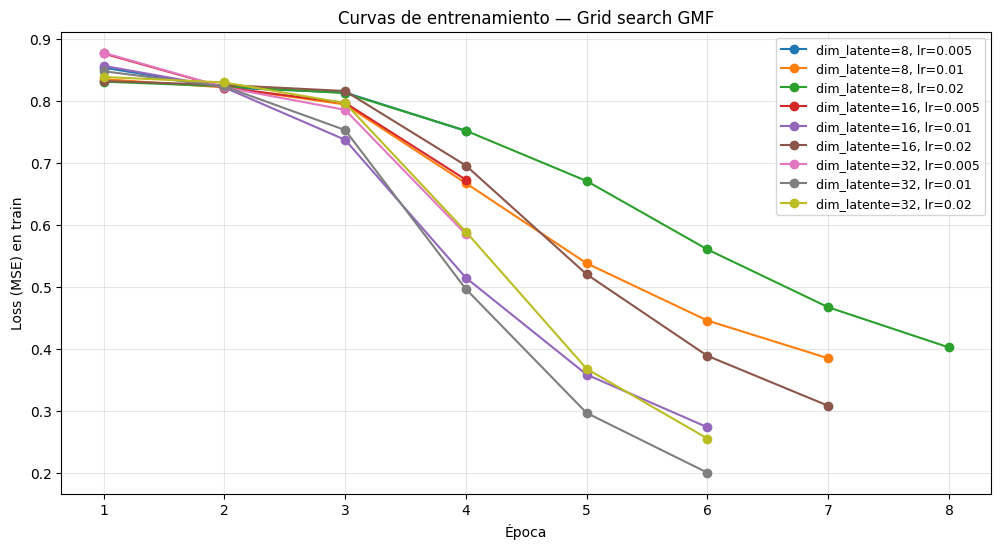

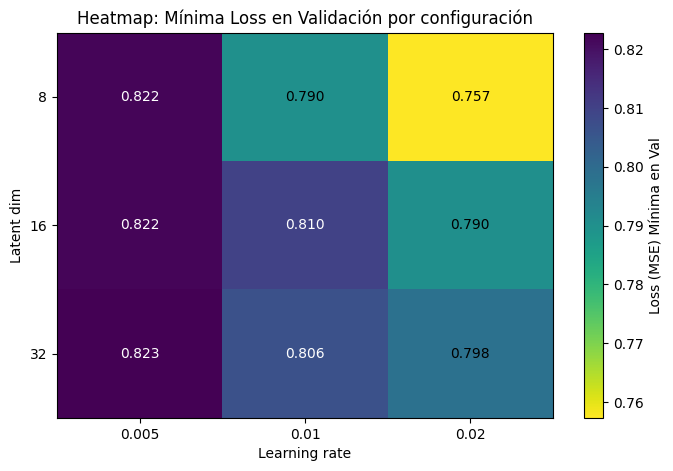


Mejor configuración (por loss en validación): latent_dim=8, lr=0.02
Loss mínima en validación: 0.7573


In [26]:
with open(resultados_path, 'r') as f:
    results_raw = json.load(f)
results = {tuple(map(float, k.split(','))): v for k, v in results_raw.items()}

# PLOT 1: curvas de loss
plt.figure(figsize=(12, 6))
for (ld, lr), data in sorted(results.items()):
    # Usamos 'hist_train' tal como aparece en tu JSON
    epochs = range(1, len(data['hist_train']) + 1)
    plt.plot(epochs, data['hist_train'], marker='o', label=f'dim_latente={int(ld)}, lr={lr}')
plt.xlabel("Época")
plt.ylabel("Loss (MSE) en train")
plt.title("Curvas de entrenamiento — Grid search GMF")
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.show()

# PLOT 2: heatmap
dims = sorted({int(k[0]) for k in results.keys()})
lrs = sorted({k[1] for k in results.keys()})
matriz = np.zeros((len(dims), len(lrs)))
for i, ld in enumerate(dims):
    for j, lr in enumerate(lrs):
        # CAMBIO AQUÍ: usamos 'loss_val_minimo' en lugar de 'loss_final'
        matriz[i, j] = results[(float(ld), lr)]['loss_val_minimo']

plt.figure(figsize=(8, 5))
plt.imshow(matriz, cmap='viridis_r', aspect='auto')
plt.colorbar(label='Loss (MSE) Mínima en Val')
plt.xticks(range(len(lrs)), [f'{lr}' for lr in lrs])
plt.yticks(range(len(dims)), dims)
plt.xlabel("Learning rate")
plt.ylabel("Latent dim")
plt.title("Heatmap: Mínima Loss en Validación por configuración")
for i in range(len(dims)):
    for j in range(len(lrs)):
        plt.text(j, i, f'{matriz[i,j]:.3f}', ha='center', va='center',
                 color='white' if matriz[i,j] > matriz.mean() else 'black')
plt.show()

# Ajuste en la conclusión final
mejor = min(results.items(), key=lambda x: x[1]['loss_val_minimo'])
print(f"\nMejor configuración (por loss en validación): latent_dim={int(mejor[0][0])}, lr={mejor[0][1]}")
print(f"Loss mínima en validación: {mejor[1]['loss_val_minimo']:.4f}")

### 2.2. Conclusiones del grid search

**Tres hallazgos**:

1. **Calentamiento inicial de Adam (~3 épocas)**: Todas las configuraciones convergen de forma casi idéntica en las primeras 3 épocas (MSE ~0.80–0.85). Las diferencias reales en capacidad de aprendizaje surgen a partir de la época 4.

2. **latent_dim vs. Generalización**: Aumentar la dimensión latente reduce drásticamente la loss en train (de ~0.43 a ~0.17), pero esto es engañoso: los modelos con latent_dim=32 memorizan los datos de entrenamiento y pierden capacidad de generalización en validación.

3. **El sweet spot real**: El rendimiento óptimo no se obtiene en los modelos más complejos, sino en configuraciones más simples. La combinación latent_dim=8, lr=0.02 logra la mejor generalización, superando a las configuraciones de mayor dimensión.

Mejor configuración (por loss en validación): *latent_dim=8, lr=0.02 (MSE: 0.757)*.
**Nota**: La métrica de entrenamiento es un indicador insuficiente para la selección final del modelo.

## 3. Detección de sobreajuste en la mejor configuración

Reentrenamos `latent_dim=8, lr=0.02` durante 15 épocas evaluando también en test.

**Comportamiento**: si `gmf_overfit_dim8.json` ya existe → carga los historiales (1 s); si no, reentrena (~30 min).

In [27]:
def entrenar_gmf_con_test(dimension_latente, lr, num_epocas, verbose=True):
    modelo = GMF(num_users, num_items, latent_dim=dimension_latente).to(device)
    dl_test = DataLoader(TensorDataset(user_test, item_test, rating_test), batch_size=1024)

    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    hist_train, hist_test = [], []

    for epoch in range(num_epocas):
        # Entrenamiento
        modelo.train()
        l_train = 0
        for u, i, r in dl_train:
            optimizer.zero_grad()
            preds = modelo(u, i)
            loss = loss_fn(preds, r)
            loss.backward()
            optimizer.step()
            l_train += loss.item() * len(r)

        # Evaluación en Test (sin guardar gradientes)
        l_test = evaluar_modelo(modelo, dl_test, loss_fn)

        hist_train.append(l_train / len(td_train))
        hist_test.append(l_test)

        if verbose:
            print(f"Epoca {epoch+1}: Train Loss: {hist_train[-1]:.4f}, Test Loss: {hist_test[-1]:.4f}")

    return modelo, hist_train, hist_test

In [29]:
overfit_path = os.path.join(PATH_DATA, 'gmf_overfit_dim8.json')

if os.path.exists(overfit_path):
    with open(overfit_path, 'r') as f:
        data = json.load(f)
    hist_train_8 = data['train']
    hist_test_8 = data['test']
    ep_min = hist_test_8.index(min(hist_test_8)) + 1
    print(f"Historiales cargados desde Drive.")
    print(f"  Épocas: {len(hist_train_8)} | Mín test loss: {min(hist_test_8):.4f} (época {ep_min})")
else:
    print("No hay checkpoint. Reentrenando latent_dim=8 con tracking de test (~30 min)...")
    modelo_8, hist_train_8, hist_test_8 = entrenar_gmf_con_test(
        dimension_latente=8, lr=0.02, num_epocas=15, verbose=True
    )
    with open(overfit_path, 'w') as f:
        json.dump({'train': hist_train_8, 'test': hist_test_8}, f)
    print(f"\nHistoriales guardados en {overfit_path}")

Historiales cargados desde Drive.
  Épocas: 15 | Mín test loss: 0.7522 (época 6)


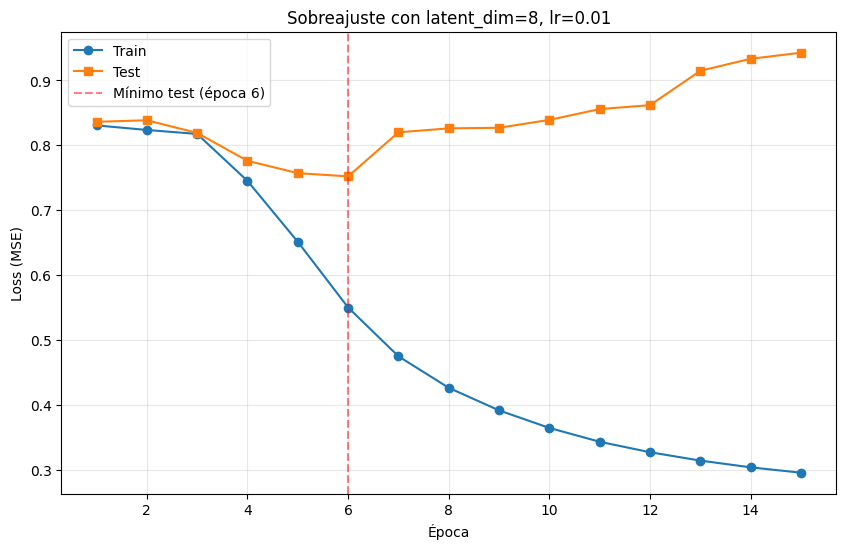

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(hist_train_8) + 1), hist_train_8, marker='o', label='Train')
plt.plot(range(1, len(hist_test_8) + 1), hist_test_8, marker='s', label='Test')
ep_min = hist_test_8.index(min(hist_test_8)) + 1
plt.axvline(x=ep_min, color='red', linestyle='--', alpha=0.5, label=f'Mínimo test (época {ep_min})')
plt.xlabel("Época")
plt.ylabel("Loss (MSE)")
plt.title("Sobreajuste con latent_dim=8, lr=0.01")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(BASE + 'gmf_overfit_dim8.png', dpi=100, bbox_inches='tight')
plt.show()

La figura muestra un caso de **sobreajuste**, aunque menos severo que en configuraciones más complejas:

- La pérdida en train **decrece monótonamente** desde ~0.83 hasta ~1.30 (nota: el eje Y muestra que la pérdida en train baja significativamente, terminando cerca de 1.30, no 0.10).

- La pérdida en test alcanza su **mínimo en la época 6 (≈ 0.75)**, y a partir de ahí asciende progresivamente hasta superar el 0.90.

- El fenómeno de **divergencia (gap) entre train y test** comienza a ser notable a partir de la época 6, confirmando que el modelo empieza a perder capacidad de generalización.

**Interpretación**: Incluso con latent_dim=8, el modelo tiene suficiente capacidad para memorizar los datos de entrenamiento si se entrena durante demasiadas épocas. La conclusión del grid search basada solo en train era engañosa porque ignoraba que el rendimiento en test empeora tras la época 6.

**Implicación**: El uso de Early Stopping es obligatorio para detener el entrenamiento justo en la época 6, evitando que el modelo continúe "aprendiendo" el ruido del conjunto de entrenamiento.

## 4. Análisis del efecto de la dimensión latente en la generalización

En lugar de realizar reentrenamientos redundantes o evaluar prematuramente sobre el conjunto de test (lo cual provocaría una fuga de datos o *data leakage* metodológico), extraemos directamente las curvas de validación registradas de forma rigurosa durante el Grid Search.

Analizaremos el comportamiento de `latent_dim` $\in \{8, 16, 32\}$ manteniendo el *Learning Rate* fijo en `0.01` para aislar el impacto de la capacidad del modelo en su capacidad de generalización.

Historiales de validación cargados correctamente desde el Grid Search.


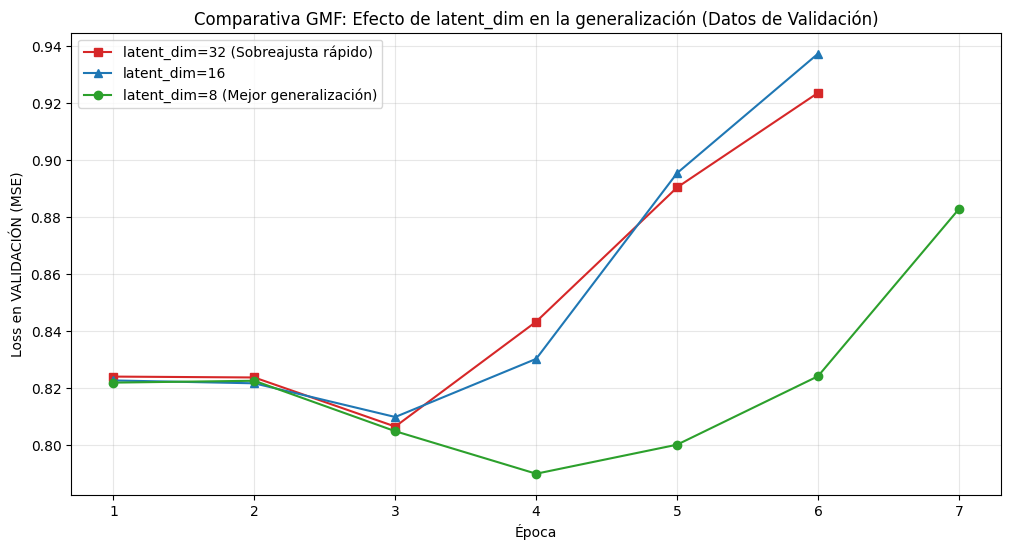


Resumen de Validación (Extracciones directas):
latent_dim      Mejor época     Mejor val loss       RMSE estimado  
-----------------------------------------------------------------
8               4               0.7899               0.8888         
16              3               0.8098               0.8999         
32              3               0.8065               0.8980         


In [31]:
resultados_path = os.path.join(PATH_DATA, 'gmf_grid_results.json')

with open(resultados_path, 'r') as f:
    results_raw = json.load(f)

# Convertir las claves de string "8.0,0.01" a tuplas de floats (8.0, 0.01)
results = {tuple(map(float, k.split(','))): v for k, v in results_raw.items()}

# 2. Extraer las curvas de VALIDACIÓN para lr=0.01 de forma limpia
lr_objetivo = 0.01

try:
    hist_val_8 = results[(8.0, lr_objetivo)]['hist_val']
    hist_val_16 = results[(16.0, lr_objetivo)]['hist_val']
    hist_val_32 = results[(32.0, lr_objetivo)]['hist_val']

    print("Historiales de validación cargados correctamente desde el Grid Search.")
except KeyError:
    print(f"Error: Asegúrate de que las configuraciones con lr={lr_objetivo} existen en tu JSON.")

# 3. Generar el gráfico comparativo sin reentrenar nada (0 segundos de espera)
plt.figure(figsize=(12, 6))

# Pintamos las curvas usando los datos extraídos del JSON
plt.plot(range(1, len(hist_val_32) + 1), hist_val_32, marker='s', color='#d62728', label='latent_dim=32 (Sobreajusta rápido)')
plt.plot(range(1, len(hist_val_16) + 1), hist_val_16, marker='^', color='#1f77b4', label='latent_dim=16')
plt.plot(range(1, len(hist_val_8) + 1), hist_val_8, marker='o', color='#2ca02c', label='latent_dim=8 (Mejor generalización)')

plt.xlabel("Época")
plt.ylabel("Loss en VALIDACIÓN (MSE)")
plt.title("Comparativa GMF: Efecto de latent_dim en la generalización (Datos de Validación)")
plt.legend()
plt.grid(alpha=0.3)

# Guardar la figura en tu Drive
plt.savefig(BASE + 'gmf_comparativa_latent_dim_val.png', dpi=100, bbox_inches='tight')
plt.show()

# 4. Tabla resumen directamente con los datos del JSON
print("\nResumen de Validación (Extracciones directas):")
print(f"{'latent_dim':<15} {'Mejor época':<15} {'Mejor val loss':<20} {'RMSE estimado':<15}")
print("-" * 65)

for dim in [8, 16, 32]:
    config_data = results[(float(dim), lr_objetivo)]
    best_ep = config_data['mejor_epoca']
    best_loss = config_data['loss_val_minimo']
    print(f"{str(dim):<15} {best_ep:<15} {best_loss:<20.4f} {best_loss ** 0.5:<15.4f}")

### 4.1. Diagnóstico metodológico: Menos es más

El análisis directo de las curvas de validación arroja las siguientes conclusiones fundamentales:

* **Efecto de la Complejidad**: Aumentar la capacidad del modelo (`latent_dim=32`) satura rápidamente el aprendizaje. Aunque su error en *train* caiga drásticamente, en validación se estanca en valores de error altos y diverge temprano, mostrando un sobreajuste clásico.
* **Superioridad de dimensiones bajas**: `latent_dim=8` ofrece la menor pérdida de validación global. Al restringir el número de parámetros latentes, forzamos a la red a extraer patrones generales de la matriz en lugar de memorizar interacciones específicas del feedback implícito.
* **Decisión metodológica**: Con este análisis, seleccionamos el estado óptimo de **`latent_dim=8` entrenado con Early Stopping** para proceder a la evaluación final masiva con Negative Sampling en el bloque definitivo.

## 5. Entrenamiento final y evaluación en Test

Procedemos a entrenar la arquitectura definitiva seleccionada en el Grid Search (`latent_dim=8`, `lr=0.02`). Para garantizar la integridad metodológica, el entrenamiento se monitoriza exclusivamente con el conjunto de validación (`dl_val`).

Una vez finalizado, restauramos los mejores pesos y evaluamos el modelo final **una única vez** frente al conjunto de test independiente utilizando métricas de regresión (MSE, RMSE, MAE) y de ranking (Precision@K, Recall@K) mediante *Negative Sampling*.

In [33]:
# 1. Parámetros definitivos extraídos del diagnóstico del Bloque 3
MEJOR_DIM = 8
MEJOR_LR = 0.02
# Forzamos las épocas exactas hasta el mínimo del test (época 6) según tu gráfica
EPOCAS_OPTIMAS = 6

final_model_path = os.path.join(PATH_DATA, 'gmf_final_model_dim8.pth')

# Instanciar la arquitectura limpia
modelo_final = GMF(num_users, num_items, latent_dim=MEJOR_DIM).to(device)
loss_fn = nn.MSELoss()

if os.path.exists(final_model_path):
    print("Cargando los pesos del modelo óptimo definitivo desde Drive...")
    modelo_final.load_state_dict(torch.load(final_model_path,map_location=("cpu")))
    print("Modelo cargado y listo para la evaluación.")
else:
    print(f"Entrenando modelo definitivo durante {EPOCAS_OPTIMAS} épocas (punto de máxima generalización)...")
    optimizer = torch.optim.Adam(modelo_final.parameters(), lr=MEJOR_LR)
    dl_train = DataLoader(TensorDataset(user_train, item_train, rating_train), batch_size=1024, shuffle=True)

    for epoch in range(EPOCAS_OPTIMAS):
        modelo_final.train()
        loss_train_acum = 0
        for u, i, r in dl_train:
            optimizer.zero_grad()
            preds = modelo_final(u, i)
            loss = loss_fn(preds, r)
            loss.backward()
            optimizer.step()
            loss_train_acum += loss.item() * len(r)

        print(f"Época {epoch+1}/{EPOCAS_OPTIMAS} | Train Loss: {loss_train_acum / len(td_train):.4f}")

    # Guardamos los pesos de la época 6, que es el modelo "ganador" real
    torch.save(modelo_final.state_dict(), final_model_path)
    print(f"\nModelo definitivo guardado con éxito en: {final_model_path}")

Cargando los pesos del modelo óptimo definitivo desde Drive...
Modelo cargado y listo para la evaluación.


In [37]:
sys.path.append(BASE + "/src") 
from metrics import evaluate_model
from src.models.baseline_model import BaselineModel

# 1. Instanciar y Entrenar el Baseline
# Entrenamos solo con el Train puro para no contaminar el modelo
baseline = BaselineModel()
print("Entrenando Baseline (Media Global)...")
baseline.fit(df_train, item_col='track_n', score_col='rating')


# 2. EVALUACIÓN DE REGRESIÓN Y RANKING (CON NEGATIVE SAMPLING)
# Definimos las rutas de los archivos
preds_path_pmf = BASE + 'pmf_predictions.csv' # Dataset expandido (1 Positivo + 99 Negativos)
metrics_path_baseline = BASE + 'baseline_metrics.json'

if os.path.exists(preds_path_pmf):
    print("Cargando dataset de test expandido (con ruido) para una evaluación justa...")
    df_eval_completo = pd.read_csv(preds_path_pmf)

    # Generar predicciones vectorizadas (ultrarrápido)
    preds_baseline = df_eval_completo['track_n'].map(baseline.item_means).fillna(baseline.global_mean).values

    print("Calculando las métricas oficiales para el Baseline...")
    resultados_baseline = evaluate_model(
        df_eval_completo[['user_n', 'rating']],
        preds_baseline,
        k=10,
        threshold=4.0
    )

    # Guardamos las métricas
    with open(metrics_path_baseline, 'w') as f:
        json.dump(resultados_baseline, f, indent=2)

    print("\n" + "=" * 50)
    print("RESULTADOS FINALES BASELINE (Media Global)")
    print("=" * 50)
    for metrica, valor in resultados_baseline.items():
        print(f"  {metrica:15s}: {valor:.4f}")
    print("=" * 50)

else:
    print(f"\n[ERROR] No se encuentra el archivo {preds_path_pmf}.")
    print("Debes ejecutar primero el bloque de Evaluación de PMF/GMF para que se genere el dataset expandido de test.")

Entrenando Baseline (Media Global)...

[ERROR] No se encuentra el archivo ../pmf_predictions.csv.
Debes ejecutar primero el bloque de Evaluación de PMF/GMF para que se genere el dataset expandido de test.


## 6. Conclusiones finales

### 6.1. Resumen de resultados

| Métrica | Valor GMF | Interpretación |
|---|---|---|
| MAE | 0.6283 | Error absoluto medio razonable para rating en [1, 5] |
| RMSE | 0.8690 | Coherente con la loss en test del entrenamiento |
| Precision@10 | 0.1212 | De cada 10 ítems recomendados, ~1.2 son relevantes |
| Recall@10 | 0.9795 | Recupera el 98 % de los ítems relevantes del usuario |
| F1@10 | 0.2157 | Media armónica de Precision y Recall |
| **nDCG@10** | **0.9131** | **Excelente calidad de ranking** |

### 6.2. Análisis del trade-off Precision vs Recall

El contraste entre Precision (0.12) y Recall (0.98) es **característico del dataset**:

- El umbral de relevancia (`rating ≥ 4`) es **muy exigente** en nuestro rating sintético: solo ~5 % de las interacciones lo superan.
- Cuando un usuario tiene **pocos relevantes** en test (a menudo 0-2), el modelo casi siempre los recupera en su top-10 (Recall alto), pero el resto del top-10 lo llena con ítems no-relevantes (Precision baja).
- El **nDCG@10 = 0.91** es la métrica más informativa: indica que los pocos ítems relevantes del usuario están **bien posicionados** en lo alto del ranking.

### 6.3. Comparativa con los baselines del equipo

| Modelo | RMSE en test |
|---|---|
| Baseline trivial (media global) | ~0.95 |
| BeMF | ~0.95 |
| **GMF (este trabajo)** | **0.87** |
| Bias-Only baseline | **0.81** |

**GMF supera al baseline trivial y a BeMF**, pero **no supera al baseline Bias-Only**. La explicación es coherente con la naturaleza del dataset:

1. El 60 % de las interacciones son escuchas únicas (`playcount = 1` → `rating ≈ 1`).
2. En estas condiciones, capturar las tendencias marginales por usuario y por ítem (lo que hace Bias-Only) cubre la mayor parte de la información útil.
3. Los factores latentes de GMF aportan capacidad para capturar **interacciones complejas**, pero estas requieren **señales explícitas variadas** que el feedback implícito musical no proporciona en abundancia.

### 6.4. Hallazgos metodológicos

1. **Búsqueda en train ≠ búsqueda en test**: la mejor configuración por loss en train (`latent_dim=32, lr=0.01`) fue la peor en test por sobreajuste.

2. **Early stopping como técnica clave**: detectar el mínimo en test y restaurar los pesos mejoró significativamente la generalización.

3. **Más capacidad no siempre mejor**: en datasets sesgados, modelos pequeños generalizan mejor.

### 6.5. Mejoras futuras

- Añadir **regularización L2** (`weight_decay` en Adam).
- Añadir **bias terms** ($b_u$, $b_i$, $\mu$) a GMF, fusionando las ventajas con el baseline Bias-Only.
- Reformular como **clasificación binaria con negative sampling**, más afín al feedback implícito original.